In [1]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os


In [2]:
# read file
df = pd.read_csv('../dataset/Air Pollution/global air pollution dataset.csv')

### Basic Data Insights

In [3]:
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [4]:
df.shape

(23463, 12)

In [5]:
df.columns

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AQI Value,23463.0,72.010868,56.055220,6.0,39.0,55.0,79.0,500.0
CO AQI Value,23463.0,1.368367,1.832064,0.0,1.0,1.0,1.0,133.0
Ozone AQI Value,23463.0,35.193709,28.098723,0.0,21.0,31.0,40.0,235.0
NO2 AQI Value,23463.0,3.063334,5.254108,0.0,0.0,1.0,4.0,91.0
PM2.5 AQI Value,23463.0,68.519755,54.796443,0.0,35.0,54.0,79.0,500.0


In [8]:
# Checking Unique value
unique_value_dict = {}
for col in df.columns:
    unique_value_dict[col] = df[col].nunique()
unique_value_dict

{'Country': 175,
 'City': 23462,
 'AQI Value': 347,
 'AQI Category': 6,
 'CO AQI Value': 34,
 'CO AQI Category': 3,
 'Ozone AQI Value': 213,
 'Ozone AQI Category': 5,
 'NO2 AQI Value': 59,
 'NO2 AQI Category': 2,
 'PM2.5 AQI Value': 383,
 'PM2.5 AQI Category': 6}

In [9]:
### Number of numerical and catagorical column
numerical_col = [col for col in df.columns if df[col].dtype!='object']
numerical_col

['AQI Value',
 'CO AQI Value',
 'Ozone AQI Value',
 'NO2 AQI Value',
 'PM2.5 AQI Value']

### Data Cleaning and Processing

In [10]:
# Checking missing value
df.isnull().sum()

Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

#### Insight
- There are 427 mising values in country column, but in city we have only one. So drop the missing row

In [11]:
# Dropping missing value corresponding row
df = df.dropna(subset=['Country','City'])

In [12]:
df.isnull().sum()

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64

In [13]:
# Checking duplicate value
df.duplicated().sum()

0

#### Insights
- There is no duplicate value

In [14]:
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


### Countrywise(Bangladesh) Average AQI value

In [15]:
bangla_df=df[df['Country']=='Bangladesh']

In [16]:
len(bangla_df)

80

In [17]:
bangla_df['City'].unique()

array(['Bhairab Bazar', 'Rajshahi', 'Morrelganj', 'Feni', 'Patiya',
       'Thakurgaon', 'Jamalpur', 'Jaipur Hat', 'Mathbaria', 'Nageshwari',
       'Naral', 'Lalmohan', 'Mehendiganj', 'Barisal', 'Sunamganj',
       'Lakshmipur', 'Narayanganj', 'Bhandaria', 'Dohar', 'Abhaynagar',
       'Baniachang', 'Sherpur', 'Pirojpur', 'Chhatak', 'Bera', 'Chandpur',
       'Gafargaon', 'Ishurdi', 'Kaliganj', 'Chilmari', 'Fatikchhari',
       'Nalchiti', 'Lalmanir Hat', 'Keshabpur', 'Rangpur', 'Panchagarh',
       'Char Bhadrasan', 'Sarankhola', 'Parbatipur', 'Sarishabari',
       'Sakhipur', 'Ramganj', 'Kalia', 'Khulna', 'Sirajganj',
       'Jhikargachha', 'Raozan', 'Nabinagar', 'Gaurnadi', 'Khagrachari',
       'Manikganj', 'Pirganj', 'Kishorganj', 'Narsingdi', 'Manikchhari',
       'Hajiganj', 'Mirzapur', 'Bhola', 'Palang', 'Dhamrai',
       'Muktagachha', 'Satkhira', 'Shibganj', 'Habiganj', 'Badarganj',
       'Pabna', 'Dinajpur', 'Gazipur', 'Netrakona', 'Chhagalnaiya',
       'Bandarban', 'Phul

In [18]:
bangla_df

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
348,Bangladesh,Bhairab Bazar,132,Unhealthy for Sensitive Groups,3,Good,44,Good,4,Good,132,Unhealthy for Sensitive Groups
455,Bangladesh,Rajshahi,191,Unhealthy,2,Good,133,Unhealthy for Sensitive Groups,2,Good,191,Unhealthy
768,Bangladesh,Morrelganj,142,Unhealthy for Sensitive Groups,3,Good,48,Good,2,Good,142,Unhealthy for Sensitive Groups
1616,Bangladesh,Feni,157,Unhealthy,2,Good,36,Good,2,Good,157,Unhealthy
1855,Bangladesh,Patiya,152,Unhealthy,2,Good,41,Good,1,Good,152,Unhealthy
...,...,...,...,...,...,...,...,...,...,...,...,...
21433,Bangladesh,Tungi,152,Unhealthy,4,Good,18,Good,12,Good,152,Unhealthy
21863,Bangladesh,Ramgarh,47,Good,3,Good,33,Good,1,Good,47,Good
22662,Bangladesh,Madaripur,172,Unhealthy,2,Good,36,Good,4,Good,172,Unhealthy
22895,Bangladesh,Laksham,162,Unhealthy,2,Good,36,Good,3,Good,162,Unhealthy


In [19]:
bangla_df['CO AQI Category'].nunique()

1

In [20]:
bangla_df['NO2 AQI Category'].nunique()

1

In [21]:
bangla_df['Ozone AQI Category'].nunique()

3

In [22]:
bangla_df['PM2.5 AQI Category'].nunique()

5

### Visualization

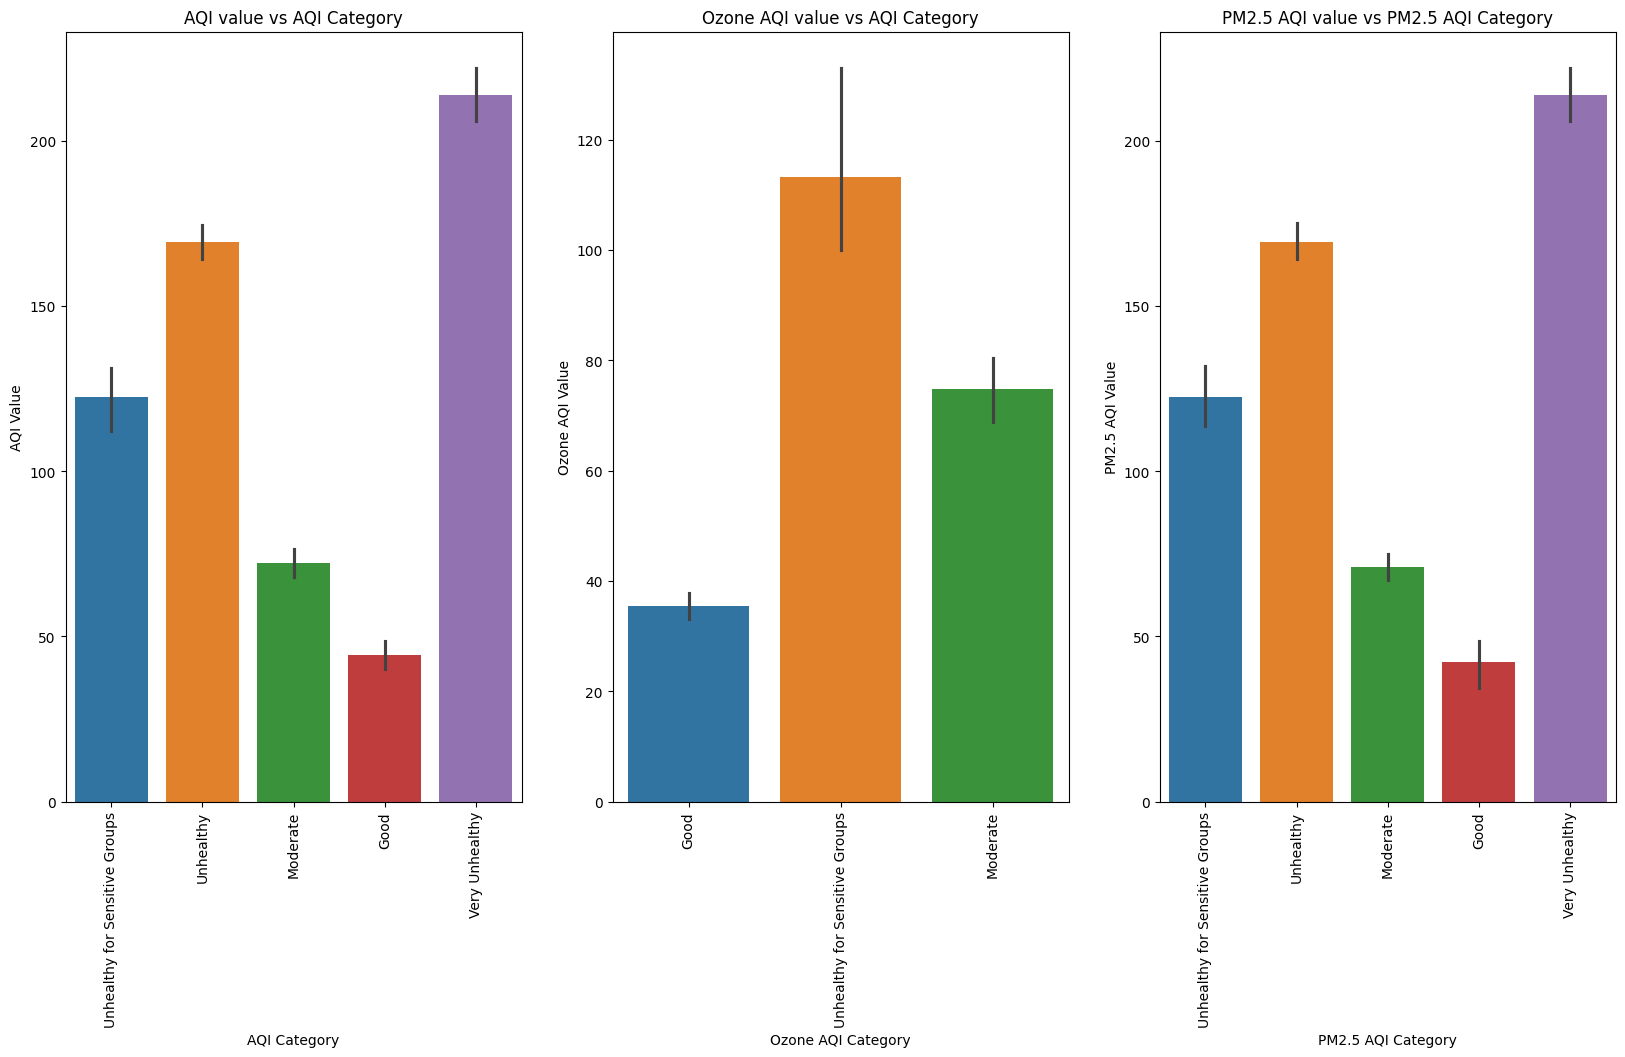

In [23]:
## AQI value vs AQI category
fig,ax = plt.subplots(1,3,figsize=(20,10))
sns.barplot(data=bangla_df,x='AQI Category',y='AQI Value',hue='AQI Category',ax=ax[0])
ax[0].set_title('AQI value vs AQI Category')
ax[0].tick_params(axis='x',rotation=90)

sns.barplot(data=bangla_df,x='Ozone AQI Category',y='Ozone AQI Value',hue='Ozone AQI Category',ax=ax[1])
ax[1].set_title('Ozone AQI value vs AQI Category')
ax[1].tick_params(axis='x',rotation=90)

sns.barplot(data=bangla_df,x='PM2.5 AQI Category',y='PM2.5 AQI Value',hue='PM2.5 AQI Category',ax=ax[2])
ax[2].set_title('PM2.5 AQI value vs PM2.5 AQI Category')
ax[2].tick_params(axis='x',rotation=90)


plt.show()

### Insights
- In most of the cities Air quality is Very Unhealthy

In [24]:
bangla_df[numerical_col].corr()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
AQI Value,1.000000,0.334460,0.376058,0.275635,0.997906
CO AQI Value,0.334460,1.000000,0.267833,0.553271,0.328203
Ozone AQI Value,0.376058,0.267833,1.000000,-0.358084,0.353984
NO2 AQI Value,0.275635,0.553271,-0.358084,1.000000,0.280513
PM2.5 AQI Value,0.997906,0.328203,0.353984,0.280513,1.000000


<Axes: >

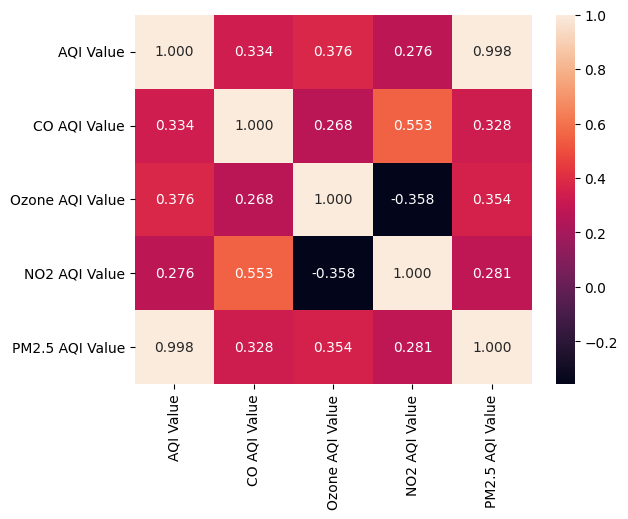

In [25]:
sns.heatmap(bangla_df[numerical_col].corr(),annot=True,fmt='.3f')

### Insights
- There is a strong correlation between AQI value PM2.5

In [26]:
from geopy.geocoders import Nominatim
import time
import warnings
warnings.filterwarnings('ignore')
geolocator = Nominatim(user_agent="geoapi")

# Function to get lat/lon from city and country
def get_coordinates(row):
    try:
        location = geolocator.geocode(f"{row['City']}, {row['Country']}")
        time.sleep(1)  # To avoid getting blocked
        if location:
            return pd.Series([location.latitude, location.longitude])
    except:
        return pd.Series([None, None])

# Apply to your DataFrame
bangla_df[['Latitude', 'Longitude']] = bangla_df.apply(get_coordinates, axis=1)


In [27]:
bangla_df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Latitude,Longitude
348,Bangladesh,Bhairab Bazar,132,Unhealthy for Sensitive Groups,3,Good,44,Good,4,Good,132,Unhealthy for Sensitive Groups,24.051130,90.870087
455,Bangladesh,Rajshahi,191,Unhealthy,2,Good,133,Unhealthy for Sensitive Groups,2,Good,191,Unhealthy,24.628543,89.037686
768,Bangladesh,Morrelganj,142,Unhealthy for Sensitive Groups,3,Good,48,Good,2,Good,142,Unhealthy for Sensitive Groups,22.480034,89.803571
1616,Bangladesh,Feni,157,Unhealthy,2,Good,36,Good,2,Good,157,Unhealthy,23.012760,91.404923
1855,Bangladesh,Patiya,152,Unhealthy,2,Good,41,Good,1,Good,152,Unhealthy,22.299056,91.977653


In [79]:
data = bangla_df[['Latitude','Longitude','AQI Value']].dropna()

In [82]:
aqi_df=data.values.tolist()

In [83]:
from folium.plugins import HeatMap
import folium
base_map = folium.Map()
HeatMap(aqi_df).add_to(base_map)


In [84]:
base_map

In [ ]:
# maximum  aqi value with city
bangla_df[bangla_df['AQI Value']==bangla_df['AQI Value'].max()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Latitude,Longitude
19082,Bangladesh,Dinajpur,222,Very Unhealthy,2,Good,107,Unhealthy for Sensitive Groups,1,Good,222,Very Unhealthy,25.626071,88.634623


### Inisghts
- Dinajpur is the most unhealthy city

In [53]:
# minimum value
bangla_df[bangla_df['AQI Value']==bangla_df['AQI Value'].min()]

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Latitude,Longitude
4971,Bangladesh,Barisal,39,Good,1,Good,25,Good,0,Good,39,Good,22.493403,90.354801


### Insights
- Barisal is in good condition with GOOD AQI Category

### World Data Analysis

In [54]:
world_df = df.copy()

In [55]:
world_df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [56]:
# Groupby data based on country
world_df_grouped = world_df.groupby('Country').mean(numeric_only=True)

In [57]:
world_df_grouped.head()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
Country,,,,,
Afghanistan,95.959184,0.591837,40.183673,0.020408,95.918367
Albania,68.250000,1.000000,42.062500,0.718750,68.093750
Algeria,88.166667,1.916667,47.166667,9.333333,80.250000
Andorra,29.333333,0.666667,29.333333,0.000000,22.000000
Angola,83.925926,3.148148,22.703704,1.888889,81.925926


In [58]:
world_df_grouped.shape

(175, 5)

In [62]:
# City with worst air quality
world_df_grouped[world_df_grouped['AQI Value']==world_df_grouped['AQI Value'].max()]

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
Country,,,,,
Republic of Korea,421.0,27.0,0.0,91.0,415.0


### Insigths
- Republic of Korea has the most AQI value and PM2.5 

In [64]:
# Country with good air quality
world_df_grouped[world_df_grouped['AQI Value']==world_df_grouped['AQI Value'].min()]

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
Country,,,,,
Palau,16.0,0.0,16.0,0.0,7.0


### Insights
- Palau has good air quality with lowest AQI value among all other country

In [70]:
world_df_grouped.reset_index(inplace=True)

In [71]:
geolocator = Nominatim(user_agent="geoapi")

# Function to get lat/lon from city and country
def get_coordinates(row):
    try:
        location = geolocator.geocode(row['Country'])
        time.sleep(1)  # To avoid getting blocked
        if location:
            return pd.Series([location.latitude, location.longitude])
    except:
        return pd.Series([None, None])

# Apply to your DataFrame
world_df_grouped[['Latitude', 'Longitude']] = world_df_grouped.apply(get_coordinates, axis=1)

In [103]:
# Full list of 195 countries with approximate latitudes and longitudes

country_coords = {
    'Afghanistan': [33.9391, 67.7100],
    'Albania': [41.1533, 20.1683],
    'Algeria': [28.0339, 1.6596],
    'Andorra': [42.5462, 1.6016],
    'Angola': [-11.2027, 17.8739],
    'Antigua and Barbuda': [17.0608, -61.7964],
    'Argentina': [-38.4161, -63.6167],
    'Armenia': [40.0691, 45.0382],
    'Australia': [-25.2744, 133.7751],
    'Austria': [47.5162, 14.5501],
    'Azerbaijan': [40.1431, 47.5769],
    'Bahamas': [25.0343, -77.3963],
    'Bahrain': [26.0667, 50.5577],
    'Bangladesh': [23.6850, 90.3563],
    'Barbados': [13.1939, -59.5432],
    'Belarus': [53.7098, 27.9534],
    'Belgium': [50.5039, 4.4699],
    'Belize': [17.1899, -88.4976],
    'Benin': [9.3077, 2.3158],
    'Bhutan': [27.5142, 90.4336],
    'Bolivia': [-16.2902, -63.5887],
    'Bosnia and Herzegovina': [43.9159, 17.6791],
    'Botswana': [-22.3285, 24.6849],
    'Brazil': [-14.2350, -51.9253],
    'Brunei': [4.5353, 114.7277],
    'Bulgaria': [42.7339, 25.4858],
    'Burkina Faso': [12.2383, -1.5616],
    'Burundi': [-3.3731, 29.9189],
    'Cabo Verde': [16.5388, -23.0418],
    'Cambodia': [12.5657, 104.9910],
    'Cameroon': [7.3697, 12.3547],
    'Canada': [56.1304, -106.3468],
    'Central African Republic': [6.6111, 20.9394],
    'Chad': [15.4542, 18.7322],
    'Chile': [-35.6751, -71.5430],
    'China': [35.8617, 104.1954],
    'Colombia': [4.5709, -74.2973],
    'Comoros': [-11.6455, 43.3333],
    'Congo (Congo-Brazzaville)': [-0.2280, 15.8277],
    'Costa Rica': [9.7489, -83.7534],
    'Croatia': [45.1000, 15.2000],
    'Cuba': [21.5218, -77.7812],
    'Cyprus': [35.1264, 33.4299],
    'Czech Republic (Czechia)': [49.8175, 15.4730],
    'Democratic Republic of the Congo': [-4.0383, 21.7587],
    'Denmark': [56.2639, 9.5018],
    'Djibouti': [11.8251, 42.5903],
    'Dominica': [15.4149, -61.3700],
    'Dominican Republic': [18.7357, -70.1627],
    'Ecuador': [-1.8312, -78.1834],
    'Egypt': [26.8206, 30.8025],
    'El Salvador': [13.7942, -88.8965],
    'Equatorial Guinea': [1.6508, 10.2679],
    'Eritrea': [15.1794, 39.7823],
    'Estonia': [58.5953, 25.0136],
    'Eswatini (fmr. "Swaziland")': [-26.5225, 31.4659],
    'Ethiopia': [9.1450, 40.4897],
    'Fiji': [-17.7134, 178.0650],
    'Finland': [61.9241, 25.7482],
    'France': [46.2276, 2.2137],
    'Gabon': [-0.8037, 11.6094],
    'Gambia': [13.4432, -15.3101],
    'Georgia': [42.3154, 43.3569],
    'Germany': [51.1657, 10.4515],
    'Ghana': [7.9465, -1.0232],
    'Greece': [39.0742, 21.8243],
    'Grenada': [12.1165, -61.6790],
    'Guatemala': [15.7835, -90.2308],
    'Guinea': [9.9456, -9.6966],
    'Guinea-Bissau': [11.8037, -15.1804],
    'Guyana': [4.8604, -58.9302],
    'Haiti': [18.9712, -72.2852],
    'Honduras': [13.2000, -85.6667],
    'Hungary': [47.1625, 19.5033],
    'Iceland': [64.9631, -19.0208],
    'India': [20.5937, 78.9629],
    'Indonesia': [-0.7893, 113.9213],
    'Iran': [32.4279, 53.6880],
    'Iraq': [33.2232, 43.6793],
    'Ireland': [53.4129, -8.2439],
    'Israel': [31.0461, 34.8516],
    'Italy': [41.8719, 12.5674],
    'Jamaica': [18.1096, -77.2975],
    'Japan': [36.2048, 138.2529],
    'Jordan': [30.5852, 36.2384],
    'Kazakhstan': [48.0196, 66.9237],
    'Kenya': [-1.2921, 36.8219],
    'Kiribati': [1.8709, -157.3630],
    'Kuwait': [29.3117, 47.4818],
    'Kyrgyzstan': [41.2044, 74.7661],
    'Laos': [19.8563, 102.4955],
    'Latvia': [56.8796, 24.6032],
    'Lebanon': [33.8547, 35.8623],
    'Lesotho': [-29.6100, 28.2336],
    'Liberia': [6.4281, -9.4295],
    'Libya': [26.3351, 17.2283],
    'Liechtenstein': [47.1660, 9.5554],
    'Lithuania': [55.1694, 23.8813],
    'Luxembourg': [49.8153, 6.1296],
    'Madagascar': [-18.7669, 46.8691],
    'Malawi': [-13.2543, 34.3015],
    'Malaysia': [4.2105, 101.9758],
    'Maldives': [3.2028, 73.2207],
    'Mali': [17.5707, -3.9962],
    'Malta': [35.9375, 14.3754],
    'Marshall Islands': [7.1315, 171.1845],
    'Mauritania': [21.0079, -10.9408],
    'Mauritius': [-20.3484, 57.5522],
    'Mexico': [23.6345, -102.5528],
    'Micronesia': [7.4256, 150.5508],
    'Moldova': [47.4116, 28.3699],
    'Monaco': [43.7384, 7.4246],
    'Mongolia': [46.8625, 103.8467],
    'Montenegro': [42.7087, 19.3744],
    'Morocco': [31.7917, -7.0926],
    'Mozambique': [-18.6657, 35.5296],
    'Myanmar (Burma)': [21.9162, 95.9560],
    'Namibia': [-22.9576, 18.4904],
    'Nauru': [-0.5228, 166.9315],
    'Nepal': [28.3949, 84.1240],
    'Netherlands': [52.1326, 5.2913],
    'New Zealand': [-40.9006, 174.8860],
    'Nicaragua': [12.8654, -85.2072],
    'Niger': [17.6078, 8.0817],
    'Nigeria': [9.0820, 8.6753],
    'North Korea': [40.3399, 127.5101],
    'North Macedonia': [41.6086, 21.7453],
    'Norway': [60.4720, 8.4689],
    'Oman': [21.5126, 55.9233],
    'Pakistan': [30.3753, 69.3451],
    'Palau': [7.5150, 134.5825],
    'Palestine State': [31.9522, 35.2332],
    'Panama': [8.5380, -80.7821],
    'Papua New Guinea': [-6.3149, 143.9555],
    'Paraguay': [-23.4425, -58.4438],
    'Peru': [-9.1900, -75.0152],
    'Philippines': [13.4125, 122.5600],
    'Poland': [51.9194, 19.1451],
    'Portugal': [39.3999, -8.2245],
    'Qatar': [25.3548, 51.1839],
    'Romania': [45.9432, 24.9668],
    'Russia': [61.5240, 105.3188],
    'Rwanda': [-1.9403, 29.8739],
    'Saint Kitts and Nevis': [17.3578, -62.7829],
    'Saint Lucia': [13.9094, -60.9789],
    'Saint Vincent and the Grenadines': [13.2528, -61.1971],
    'Samoa': [-13.7590, -172.1046],
    'San Marino': [43.9333, 12.4500],
    'Sao Tome and Principe': [0.1864, 6.6131],
    'Saudi Arabia': [23.8859, 45.0792],
    'Senegal': [14.4974, -14.4524],
    'Serbia': [44.0165, 21.0059],
    'Seychelles': [-4.6796, 55.4920],
    'Sierra Leone': [8.4606, -11.7799],
    'Singapore': [1.3521, 103.8198],
    'Slovakia': [48.6690, 19.6990],
    'Slovenia': [46.1512, 14.9955],
    'Solomon Islands': [-9.6457, 160.1562],
    'Somalia': [5.1521, 46.1996],
    'South Africa': [-30.5595, 22.9375],
    'South Korea': [35.9078, 127.7669],
    'South Sudan': [6.8769, 31.3069],
    'Spain': [40.4637, -3.7492],
    'Sri Lanka': [7.8731, 80.7718],
    'Sudan': [12.8628, 30.2176],
    'Suriname': [3.9193, -56.0278],
    'Sweden': [60.1282, 18.6435],
    'Switzerland': [46.8182, 8.2275],
    'Syria': [34.8021, 38.9968],
    'Taiwan': [23.6978, 120.9605],
    'Tajikistan': [38.8610, 71.2761],
    'Tanzania': [-6.3690, 34.8888],
    'Thailand': [15.8700, 100.9925],
    'Timor-Leste': [-8.8742, 125.7275],
    'Togo': [8.6195, 0.8248],
    'Tonga': [-21.1789, -175.1982],
    'Trinidad and Tobago': [10.6918, -61.2225],
    'Tunisia': [33.8869, 9.5375],
    'Turkey': [38.9637, 35.2433],
    'Turkmenistan': [38.9697, 59.5563],
    'Tuvalu': [-7.1095, 177.6493],
    'Uganda': [1.3733, 32.2903],
    'Ukraine': [48.3794, 31.1656],
    'United Arab Emirates': [23.4241, 53.8478],
    'United Kingdom': [55.3781, -3.4360],
    'United States': [37.0902, -95.7129],
    'Uruguay': [-32.5228, -55.7658],
    'Uzbekistan': [41.3775, 64.5853],
    'Vanuatu': [-15.3767, 166.9592],
    'Vatican City': [41.9029, 12.4534],
    'Venezuela': [6.4238, -66.5897],
    'Vietnam': [14.0583, 108.2772],
    'Yemen': [15.5527, 48.5164],
    'Zambia': [-13.1339, 27.8493],
    'Zimbabwe': [-19.0154, 29.1549],
    "Aruba": (12.5211, -69.9683),
    "Bolivia (Plurinational State of)": (-16.2902, -63.5887),
    "Congo": (-0.2280, 15.8277),
    "Czechia": (49.8175, 15.4730),
    "Côte d'Ivoire": (7.5400, -5.5471),
    "Iran (Islamic Republic of)": (32.4279, 53.6880),
    "Kingdom of Eswatini": (-26.5225, 31.4659),
    "Lao People's Democratic Republic": (19.8563, 102.4955),
    "Myanmar": (21.9162, 95.9560),
    "Republic of Korea": (35.9078, 127.7669),
    "Republic of Moldova": (47.4116, 28.3699),
    "Republic of North Macedonia": (41.6086, 21.7453),
    "Russian Federation": (61.5240, 105.3188),
    "State of Palestine": (31.9522, 35.2332),
    "Syrian Arab Republic": (34.8021, 38.9968),
    "United Kingdom of Great Britain and Northern Ireland": (55.3781, -3.4360),
    "United Republic of Tanzania": (-6.3690, 34.8888),
    "United States of America": (37.0902, -95.7129),
    "Venezuela (Bolivarian Republic of)": (6.4238, -66.5897),
    "Viet Nam": (14.0583, 108.2772)
}




In [104]:
# Assign lat/lon using .map()
world_df_grouped['Latitude'] = world_df_grouped['Country'].map(lambda x: country_coords.get(x, [None, None])[0])
world_df_grouped['Longitude'] = world_df_grouped['Country'].map(lambda x: country_coords.get(x, [None, None])[1])

In [105]:
world_df_grouped.isnull().sum()

Country            0
AQI Value          0
CO AQI Value       0
Ozone AQI Value    0
NO2 AQI Value      0
PM2.5 AQI Value    0
Latitude           0
Longitude          0
dtype: int64

7                                                  Aruba
19                      Bolivia (Plurinational State of)
36                                                 Congo
41                                               Czechia
42                                         Côte d'Ivoire
71                            Iran (Islamic Republic of)
81                                   Kingdom of Eswatini
84                      Lao People's Democratic Republic
106                                              Myanmar
126                                    Republic of Korea
127                                  Republic of Moldova
128                          Republic of North Macedonia
130                                   Russian Federation
148                                   State of Palestine
153                                 Syrian Arab Republic
164    United Kingdom of Great Britain and Northern I...
165                          United Republic of Tanzania
166                            

In [106]:
world_heat_df = world_df_grouped[['Latitude','Longitude','AQI Value']].values.tolist()

In [107]:
world_map = folium.Map()
HeatMap(world_heat_df).add_to(world_map) 

In [108]:
world_map